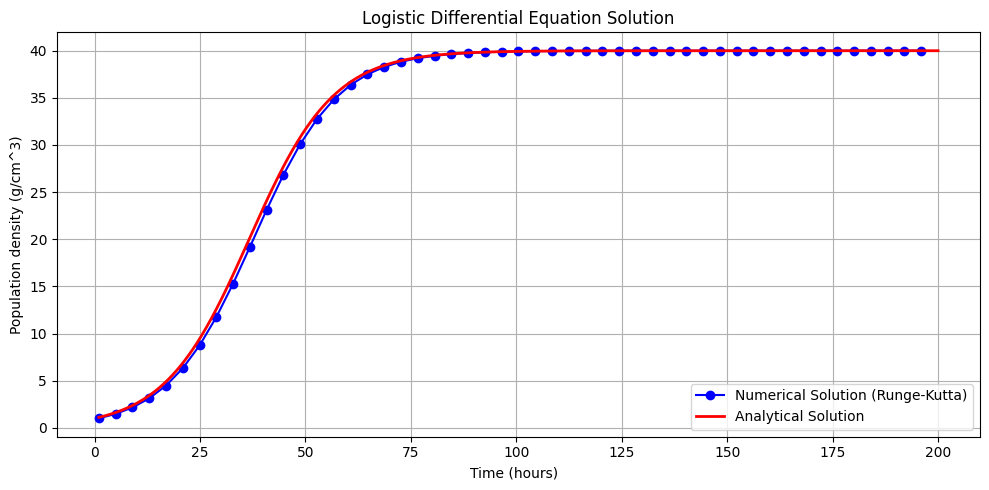

In [3]:
import numpy as np
from src import  log_dif_eq,analytic_sol

In [4]:
import pandas as pd
import yaml

with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

data=pd.read_excel(f'../{config["raw_data_path"]}', skiprows=8)
data=data.drop(columns=[f'Unnamed: {k}' for k in range(4)])
data_long = pd.melt(data, id_vars='Tiempo de Fermentacón (h)', var_name='Tratamiento', value_name='Concentración (g/cm3)')

data_long.head()

,Tiempo de Fermentacón (h),Tratamiento,Concentración (g/cm3)
0,0,Testigo (T1) Kéfir sin ultrasonicar,14.326143
1,12,Testigo (T1) Kéfir sin ultrasonicar,19.984467
2,24,Testigo (T1) Kéfir sin ultrasonicar,25.117400
3,36,Testigo (T1) Kéfir sin ultrasonicar,34.613600
4,48,Testigo (T1) Kéfir sin ultrasonicar,38.470333


In [13]:
no_treatment = data_long["Tratamiento"]=="Testigo (T1) Kéfir sin ultrasonicar"
data = data_long[ no_treatment ]
data = data[ ["Tiempo de Fermentacón (h)","Concentración (g/cm3)"] ]
initial_cond= data ["Concentración (g/cm3)"][0]

# Diff Eq. Parameters
parameters=[(0.001*i,50,initial_cond) for i in range(1,1000)]

# Runge-Kutta Parameters
domain=( 0, 170 )
n_points=100


best_params = None
best_error = float("inf")
for p in parameters:
    R,K,Y_0=p

    f=lambda x, y: log_dif_eq(y=y, x=x, r=R, k=K)

    analytic_solution = analytic_sol(y0=Y_0, interval=domain,r=R,k=K)
    x_analytic, y_analytic = zip(*analytic_solution)
    y_pred = np.interp(data["Tiempo de Fermentacón (h)"], x_analytic, y_analytic)

    error = np.mean((data["Concentración (g/cm3)"].values - y_pred) ** 2)
    if error < best_error:
        best_error = error
        best_params = (R, K, Y_0)



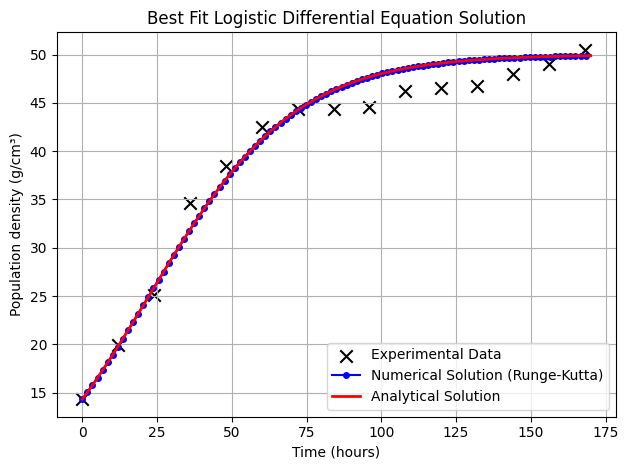

In [14]:
import matplotlib.pyplot as plt
from src import runge_kutta

R, K, Y_0 = best_params

numeric_solution = runge_kutta(f=f,y0=Y_0, interval=domain,n=n_points)
analytic_solution = analytic_sol(y0=Y_0, interval=domain,r=R,k=K)



# Plot

x_numeric, y_numeric = zip(*numeric_solution)
x_analytic, y_analytic = zip(*analytic_solution)

plt.scatter(data["Tiempo de Fermentacón (h)"],
            data["Concentración (g/cm3)"],
            label="Experimental Data",
            color="black",
            marker="x",
            s=80)

# Numerical RK4 solution
plt.plot(x_numeric, y_numeric,
         label='Numerical Solution (Runge-Kutta)',
         color='blue',
         marker='o',
         markersize=4)

# Analytical solution
plt.plot(x_analytic, y_analytic,
         label='Analytical Solution',
         color='red',
         linewidth=2)

plt.title("Best Fit Logistic Differential Equation Solution")
plt.xlabel("Time (hours)")
plt.ylabel("Population density (g/cm³)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("plots/best_adj.png", dpi=300)
plt.show()

In [15]:
print(best_params)

(0.041, 50, np.float64(14.326143333333334))
